In [3]:
import numpy as np
import scipy.io
import matplotlib.pyplot as plt

cal_masks_path = '/home/xkw/pxlames/segmentation/outputs/testResults/FIVE-BceDiceSmooth_V3_0.5_0.2_0.0001_4/cal_gt_masks.npy'
cal_scores_path = '/home/xkw/pxlames/segmentation/outputs/testResults/FIVE-BceDiceSmooth_V3_0.5_0.2_0.0001_4/cal_scores.npy'
test_masks_path = '/home/xkw/pxlames/segmentation/outputs/testResults/FIVE-BceDiceSmooth_V3_0.5_0.2_0.0001_4/gt_masks.npy'
test_scores_path = '/home/xkw/pxlames/segmentation/outputs/testResults/FIVE-BceDiceSmooth_V3_0.5_0.2_0.0001_4/scores.npy'
cal_masks = np.load(cal_masks_path)
cal_scores = np.load(cal_scores_path)
test_masks = np.load(test_masks_path)
test_scores = np.load(test_scores_path)

# 重塑数组
cal_masks = np.transpose(cal_masks, (1, 2, 0))
cal_scores = np.transpose(cal_scores, (1, 2, 0))
test_masks = np.transpose(test_masks, (1, 2, 0))
test_scores = np.transpose(test_scores, (1, 2, 0))


cal_masks_path2 = '/home/xkw/pxlames/segmentation/outputs/testResults/FIVE_BceDice_0.0001_4/cal_gt_masks.npy'
cal_scores_path2 = '/home/xkw/pxlames/segmentation/outputs/testResults/FIVE_BceDice_0.0001_4/cal_scores.npy'
test_masks_path2 = '/home/xkw/pxlames/segmentation/outputs/testResults/FIVE_BceDice_0.0001_4/gt_masks.npy'
test_scores_path2 = '/home/xkw/pxlames/segmentation/outputs/testResults/FIVE_BceDice_0.0001_4/scores.npy'
cal_masks2 = np.load(cal_masks_path2)
cal_scores2 = np.load(cal_scores_path2)
test_masks2 = np.load(test_masks_path2)
test_scores2 = np.load(test_scores_path2)

# 重塑数组
cal_masks2 = np.transpose(cal_masks2, (1, 2, 0))
cal_scores2 = np.transpose(cal_scores2, (1, 2, 0))
test_masks2 = np.transpose(test_masks2, (1, 2, 0))
test_scores2 = np.transpose(test_scores2, (1, 2, 0))


print("成功加载gt_masks和scores文件")


# # 定义切片参数
# patch_size = 2048  # 每个切片的大小
# stride = 2048  # 切片的步长

# # 创建切片
# cal_patches_scores = []
# cal_patches_masks = []
# test_patches_scores = []
# test_patches_masks = []

# h, w = cal_scores.shape[0], cal_scores.shape[1]
# for img_idx in range(cal_scores.shape[2]):
#     for i in range(0, h-patch_size+1, stride):
#         for j in range(0, w-patch_size+1, stride):
#             cal_patches_scores_patch = cal_scores[i:i+patch_size, j:j+patch_size, img_idx]
#             cal_patches_masks_patch= cal_masks[i:i+patch_size, j:j+patch_size, img_idx]
#             if np.any(cal_patches_masks_patch):
#                 cal_patches_scores.append(cal_patches_scores_patch)
#                 cal_patches_masks.append(cal_patches_masks_patch)
# print("校准集切片完成")

# for img_idx in range(test_scores.shape[2]):
#     for i in range(0, h-patch_size+1, stride):
#         for j in range(0, w-patch_size+1, stride):
#             test_patches_scores_patch = test_scores[i:i+patch_size, j:j+patch_size, img_idx]
#             test_patches_masks_patch = test_masks[i:i+patch_size, j:j+patch_size, img_idx]
#             if np.any(test_patches_masks_patch):
#                 test_patches_scores.append(test_patches_scores_patch)
#                 test_patches_masks.append(test_patches_masks_patch)
# print("测试集切片完成")
# # 将切片转换为numpy数组
# cal_patches_scores = np.array(cal_patches_scores)
# cal_patches_masks = np.array(cal_patches_masks)
# test_patches_scores = np.array(test_patches_scores)
# test_patches_masks = np.array(test_patches_masks)

# # 重塑数组为所需的形状
# cal_patches_scores = np.transpose(cal_patches_scores, (1, 2, 0))
# cal_patches_masks = np.transpose(cal_patches_masks, (1, 2, 0))
# test_patches_scores = np.transpose(test_patches_scores, (1, 2, 0))
# test_patches_masks = np.transpose(test_patches_masks, (1, 2, 0))

# print(f"切片后的形状:")
# print(f"patches_scores形状: {cal_patches_scores.shape}")
# print(f"patches_masks形状: {cal_patches_masks.shape}")


# print(f"\n数据集划分:")
# print(f"校准集大小: {cal_patches_scores.shape[2]} 个切片")
# print(f"验证集大小: {test_patches_scores.shape[2]} 个切片")

成功加载gt_masks和scores文件


选择第 139 个切片进行可视化


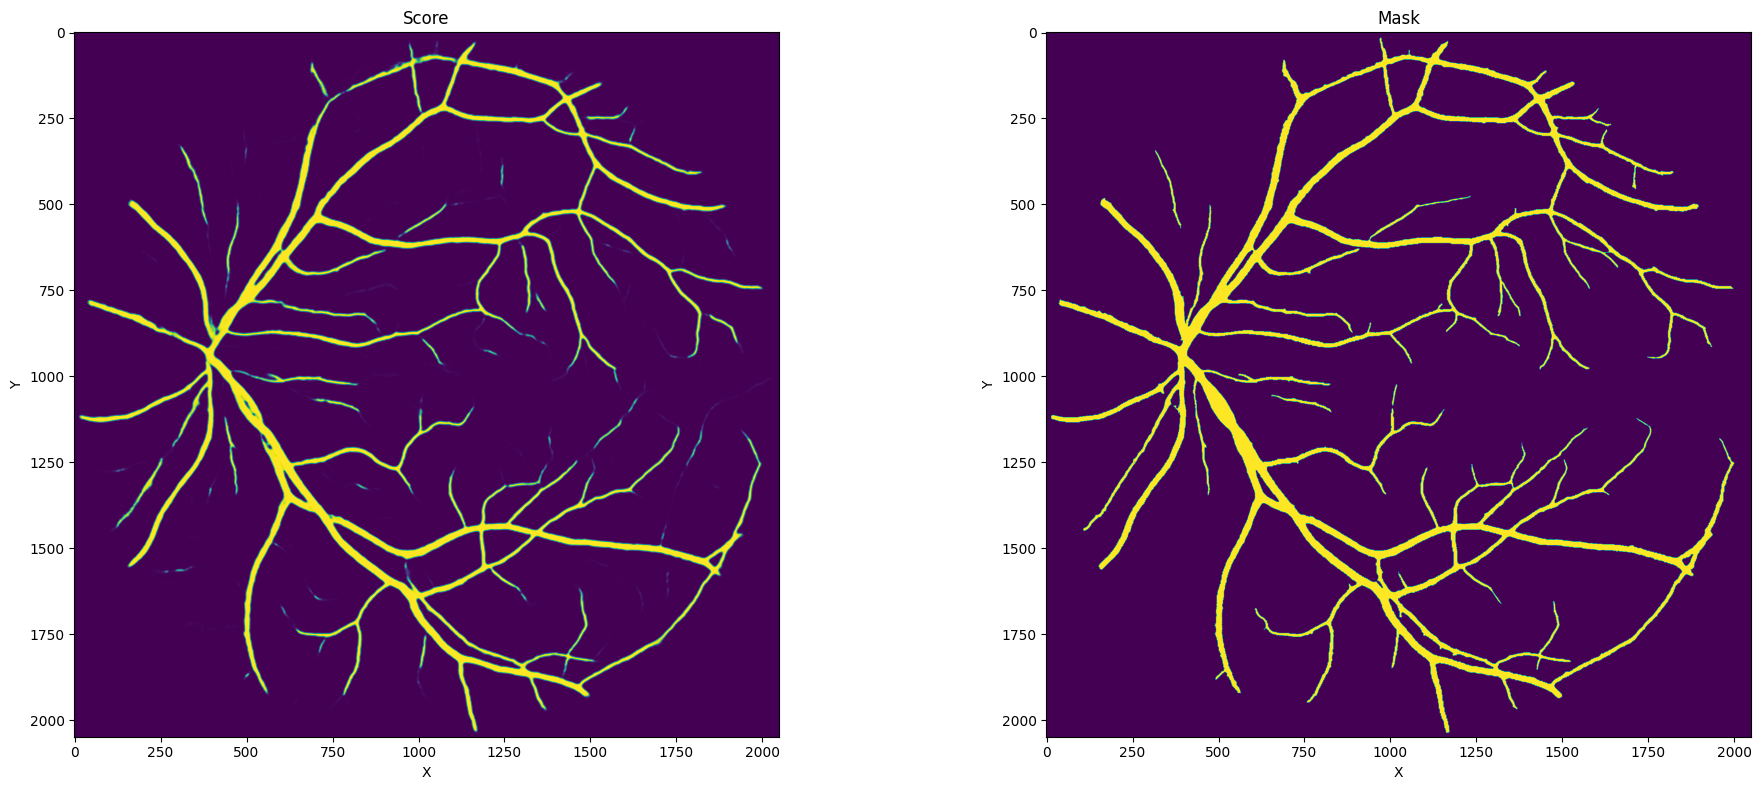

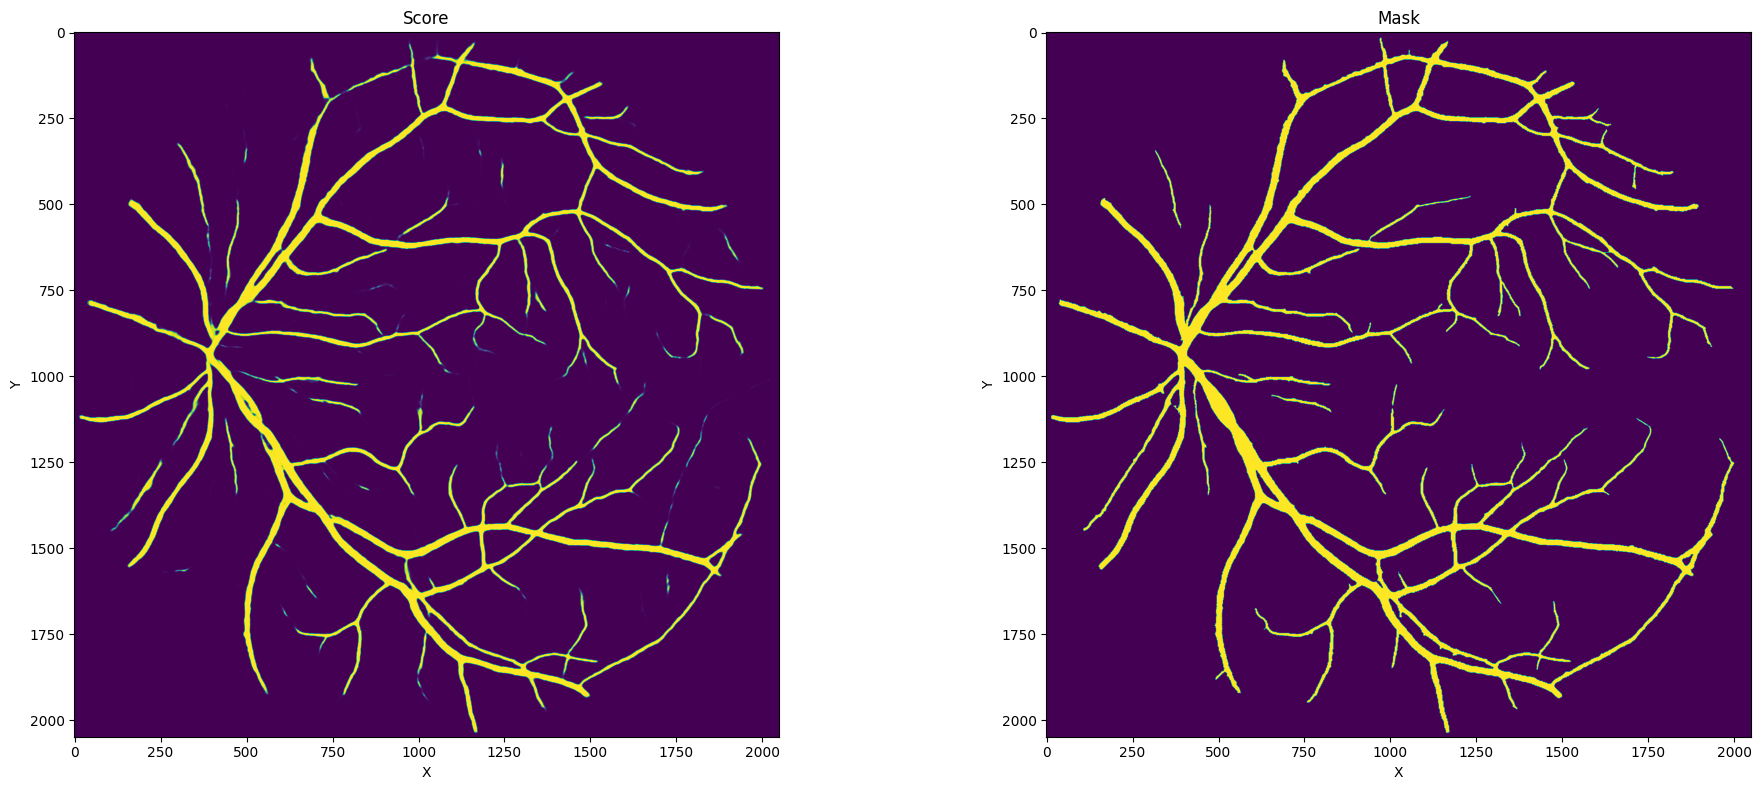

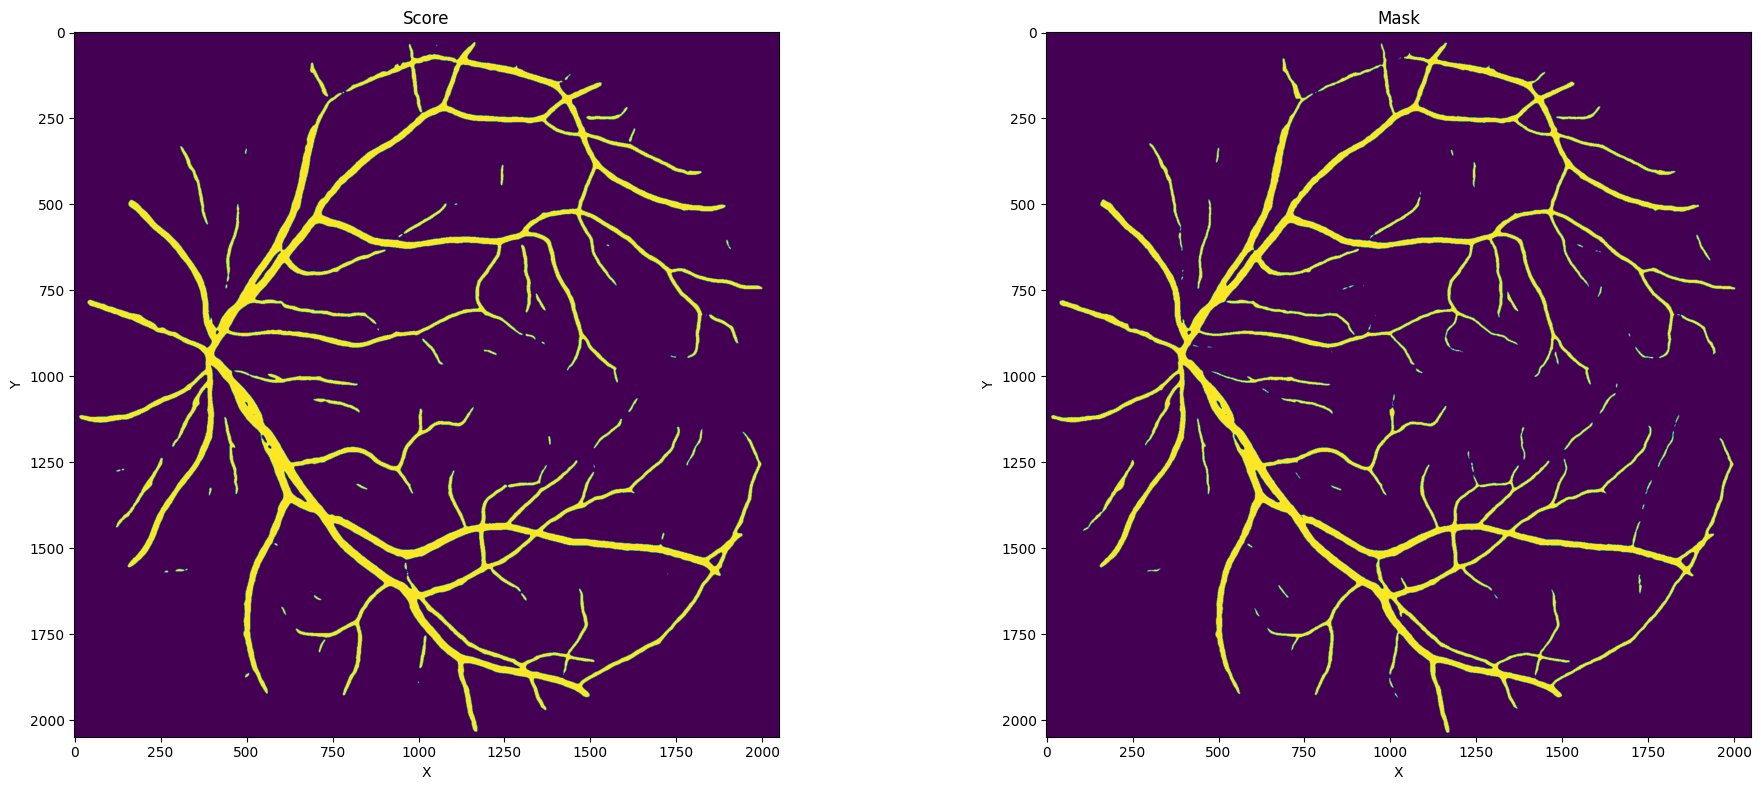

In [4]:
from skimage.segmentation import find_boundaries
import torch

# 随机选择一个切片进行可视化
id = np.random.randint(0, cal_scores.shape[2])
#id = 24193
scores = cal_scores[:,:,id]
mask = cal_masks[:,:,id]
boundary = find_boundaries(mask, mode='inner')  # mode 可以是 'inner', 'outer', 'thick'

print(f"选择第 {id} 个切片进行可视化")
# 绘制图像
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# 第一个子图显示scores
ax1.imshow(scores)
ax1.set_title('Score')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')

# 第二个子图显示mask
ax2.imshow(mask)
ax2.set_title('Mask') 
ax2.set_xlabel('X')
ax2.set_ylabel('Y')

plt.tight_layout()
plt.show()

# 绘制图像
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))


scores2 = cal_scores2[:,:,id]
mask2 = cal_masks2[:,:,id]
boundary2 = find_boundaries(mask2, mode='inner')  # mode 可以是 'inner', 'outer', 'thick'
# 第一个子图显示scores
ax1.imshow(scores2)
ax1.set_title('Score')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
# 第二个子图显示mask
ax2.imshow(mask2)
ax2.set_title('Mask') 
ax2.set_xlabel('X')
ax2.set_ylabel('Y')

plt.tight_layout()
plt.show()


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# 第一个子图显示scores
ax1.imshow(scores > 0.2)
ax1.set_title('Score')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
# 第二个子图显示mask
ax2.imshow(scores2 > 0.2)
ax2.set_title('Mask') 
ax2.set_xlabel('X')
ax2.set_ylabel('Y')

plt.tight_layout()
plt.show()


def smoothness_loss(pred, mask, lambda_smooth=1.0, eps=1e-6, threshold=0.3):
    """
    计算血管区域内部的平滑约束项，只对梯度差值大于阈值的像素进行统计。

    参数:
        pred (torch.Tensor): 分割网络的输出，形状为 (batch_size, channels, height, width)
        mask (torch.Tensor): 血管区域的掩码，形状为 (batch_size, channels, height, width)
                            1表示血管区域，0表示背景
        lambda_smooth (float): 平滑项的权重系数，默认为 1.0
        eps (float): 数值稳定性的小常数，默认为 1e-6
        threshold (float): 梯度差值的阈值，默认为 0.1

    返回:
        smooth_loss (torch.Tensor): 血管区域内部的平滑约束项的值
    """
    assert mask.shape == pred.shape, "掩码和预测的形状必须相同"
    
    # 计算内部区域的掩码（排除与背景相邻的边界像素）
    # 通过对掩码进行腐蚀操作来获得内部区域
    kernel = torch.ones(3, 3, device=mask.device)
    mask_inner = torch.nn.functional.conv2d(
        mask,
        kernel.view(1, 1, 3, 3),
        padding=1
    ) >= 9  # 只有周围8个像素都是1的点才保留

    # 计算水平和垂直方向的梯度
    grad_x = torch.abs(pred[:, :, :, 1:] - pred[:, :, :, :-1]) + eps
    grad_y = torch.abs(pred[:, :, 1:, :] - pred[:, :, :-1, :]) + eps

    # 应用内部区域掩码
    mask_x = mask_inner[:, :, :, :-1]
    mask_y = mask_inner[:, :, :-1, :]
    
    grad_x = grad_x * mask_x
    grad_y = grad_y * mask_y

    # 筛选梯度差值大于阈值的像素
    grad_x = grad_x[grad_x > threshold]
    grad_y = grad_y[grad_y > threshold]

    # 计算有效像素数量（梯度差值大于阈值的像素数量）
    num_valid_pixels = (grad_x.numel() + grad_y.numel() + eps)

    # 计算平滑约束项
    if num_valid_pixels > eps:
        smooth_loss = lambda_smooth * (grad_x.sum() + grad_y.sum()) / num_valid_pixels
    else:
        # 如果没有像素满足条件，返回 0
        smooth_loss = torch.tensor(0.0, device=pred.device)

    return smooth_loss

In [15]:
def torch_dice_fn_bce(pred, target): #pytorch tensors NCDHW
    num = pred.size(0)
    # 对预测结果进行0.5阈值化
    pred = (pred > 0.2).float()
    m1 = pred.view(num, -1).float()  # Flatten 
    m2 = target.view(num, -1).float()  # Flatten
    intersection = (m1 * m2).sum().float()

    return (2. * intersection) / (m1.sum() + m2.sum())


import torch
import torch.nn as nn
import torch.nn.functional as F

class SoftSkeletonize(torch.nn.Module):

    def __init__(self, num_iter=40):

        super(SoftSkeletonize, self).__init__()
        self.num_iter = num_iter

    def soft_erode(self, img):

        if len(img.shape)==4:
            p1 = -F.max_pool2d(-img, (3,1), (1,1), (1,0))
            p2 = -F.max_pool2d(-img, (1,3), (1,1), (0,1))
            return torch.min(p1,p2)
        elif len(img.shape)==5:
            p1 = -F.max_pool3d(-img,(3,1,1),(1,1,1),(1,0,0))
            p2 = -F.max_pool3d(-img,(1,3,1),(1,1,1),(0,1,0))
            p3 = -F.max_pool3d(-img,(1,1,3),(1,1,1),(0,0,1))
            return torch.min(torch.min(p1, p2), p3)

    def soft_dilate(self, img):

        if len(img.shape)==4:
            return F.max_pool2d(img, (3,3), (1,1), (1,1))
        elif len(img.shape)==5:
            return F.max_pool3d(img,(3,3,3),(1,1,1),(1,1,1))

    def soft_open(self, img):
        
        return self.soft_dilate(self.soft_erode(img))

    def soft_skel(self, img):

        img1 = self.soft_open(img)
        skel = F.relu(img-img1)

        for j in range(self.num_iter):
            img = self.soft_erode(img)
            img1 = self.soft_open(img)
            delta = F.relu(img-img1)
            skel = skel + F.relu(delta - skel * delta)

        return skel

    def forward(self, img):

        return self.soft_skel(img)
class soft_cldice(nn.Module):
    def __init__(self, iter_=3, smooth = 1., exclude_background=False):
        super(soft_cldice, self).__init__()
        self.iter = iter_
        self.smooth = smooth
        self.soft_skeletonize = SoftSkeletonize(num_iter=10)
        self.exclude_background = exclude_background

    def forward(self, y_true, y_pred):
        if self.exclude_background:
            y_true = y_true[:, 1:, :, :]
            y_pred = y_pred[:, 1:, :, :]
        skel_pred = self.soft_skeletonize(y_pred)
        skel_true = self.soft_skeletonize(y_true)
        tprec = (torch.sum(torch.multiply(skel_pred, y_true))+self.smooth)/(torch.sum(skel_pred)+self.smooth)    
        tsens = (torch.sum(torch.multiply(skel_true, y_pred))+self.smooth)/(torch.sum(skel_true)+self.smooth)    
        cl_dice = 1.- 2.0*(tprec*tsens)/(tprec+tsens)
        return cl_dice


def soft_dice(y_true, y_pred):
    """[function to compute dice loss]

    Args:
        y_true ([float32]): [ground truth image]
        y_pred ([float32]): [predicted image]

    Returns:
        [float32]: [loss value]
    """
    smooth = 1
    intersection = torch.sum((y_true * y_pred))
    coeff = (2. *  intersection + smooth) / (torch.sum(y_true) + torch.sum(y_pred) + smooth)
    return (1. - coeff)


class soft_dice_cldice(nn.Module):
    def __init__(self, iter_=3, alpha=0.5, smooth = 1., exclude_background=False):
        super(soft_dice_cldice, self).__init__()
        self.iter = iter_
        self.smooth = smooth
        self.alpha = alpha
        self.soft_skeletonize = SoftSkeletonize(self.iter)
        self.exclude_background = exclude_background

    def forward(self, y_true, y_pred):
        if self.exclude_background:
            y_true = y_true[:, 1:, :, :]
            y_pred = y_pred[:, 1:, :, :]
        dice = soft_dice(y_true, y_pred)
        skel_pred = self.soft_skeletonize(y_pred)
        skel_true = self.soft_skeletonize(y_true)
        tprec = (torch.sum(torch.multiply(skel_pred, y_true))+self.smooth)/(torch.sum(skel_pred)+self.smooth)    
        tsens = (torch.sum(torch.multiply(skel_true, y_pred))+self.smooth)/(torch.sum(skel_true)+self.smooth)    
        cl_dice = 1.- 2.0*(tprec*tsens)/(tprec+tsens)
        return (1.0-self.alpha)*dice+self.alpha*cl_dice
    
    
    

# 将scores和mask转换为tensor
scores_tensor = torch.from_numpy(scores).unsqueeze(0).unsqueeze(0).float()
scores_tensor2 = torch.from_numpy(scores2).unsqueeze(0).unsqueeze(0).float()
mask_tensor = torch.from_numpy(mask).unsqueeze(0).unsqueeze(0).float()
mask_tensor2 = torch.from_numpy(mask2).unsqueeze(0).unsqueeze(0).float()

print(smoothness_loss(scores_tensor, mask_tensor,threshold=0.2))
print(smoothness_loss(scores_tensor2, mask_tensor2,threshold=0.2))


# 计算dice系数
dice_score1 = torch_dice_fn_bce(scores_tensor, mask_tensor)
dice_score2 = torch_dice_fn_bce(scores_tensor2, mask_tensor2)

print(f"第一组图像的Dice系数: {dice_score1:.4f}")
print(f"第二组图像的Dice系数: {dice_score2:.4f}")

soft_dice_cldice_loss = soft_dice_cldice(iter_=50, alpha=0.5, smooth=1.)
cldice_score1 = soft_dice_cldice_loss(mask_tensor, scores_tensor)
cldice_score2 = soft_dice_cldice_loss(mask_tensor2, scores_tensor2)
print(f"第一组图像的clDice系数: {1-cldice_score1:.4f}")
print(f"第二组图像的clDice系数: {1-cldice_score2:.4f}")



tensor(0.2300)
tensor(0.4968)
第一组图像的Dice系数: 0.9113
第二组图像的Dice系数: 0.9078
第一组图像的clDice系数: 0.8943
第二组图像的clDice系数: 0.9105
